# Investigating Vibrant Planet's California Structure Graph Data

Kathryn Wheeler, Ph.D.

Data from: https://www.vpdatacommons.org/datasets/ca-stucture-graph-data
Data story: https://www.vpdatacommons.org/datasets/ca-stucture-graph-data

Overall exploratory questions:
* How much data is there? And general summary statistics?
* How much is in areas where building connectivity matters?
* Correlations between variables? Which ones might be kept and used vs which are repetitive?
* Find some interesting counties to further focus on
* Additional explorations for research questions I might have

## Notes about data download. To fully run this notebook from scratch, data must be downloaded and placed inside a "Data" folder within this repo. The code is set up to download data when missing to this repo, with a couple exceptions:
* Structure graph node data from: https://www.vpdatacommons.org/datasets/ca-stucture-graph-data
* Zip file of data from Riley et al. (2025): https://www.fs.usda.gov/rds/archive/catalog/RDS-2025-0006

An additional note about data download, most of these I would have downloaded via Google Earth Engine, but decided to download them from the source here so that it is easier for someone else to replicate without having to create a GEE project and authenticate it. 

## Import libraries, set some constant variables, define file paths

In [1]:
%load_ext autoreload
%autoreload 2
    
import geopandas as gpd
import matplotlib.pyplot as plt
from node_summaries import summarize_nodes
from pathlib import Path
from shapely.geometry import Point
import pandas as pd
import rasterio
import numpy as np


DATA_DIR = "Data/" #Directory where data is stored
county_file = Path("Data/ca_counties.gpkg")
county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

## Read in node data, look for missing data, general summary statistics

102,461 nodes with no objectid. Number of them with a value in each column:
objectid                0
degree_100              0
degree_50               0
degree_10               0
clustering_coef         0
mean_ssd                0
min_ssd                 0
geometry           102461
Non-empty footprints: 102,461
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 13527672 entries, 0 to 13527671
Data columns (total 8 columns):
 #   Column           Dtype   
---  ------           -----   
 0   objectid         str     
 1   degree_100       float64 
 2   degree_50        float64 
 3   degree_10        float64 
 4   clustering_coef  object  
 5   mean_ssd         float64 
 6   min_ssd          float64 
 7   geometry         geometry
dtypes: float64(5), geometry(1), object(1), str(1)
memory usage: 1.2+ GB


### Summary of all 13,527,672 buildings

,count,missing,decimal_places,mean,median,std,min,25%,75%,max
degree_10,"13,527,672",0,0,2.294,2.000,1.646,0.000,1.000,3.000,65.000
degree_50,"13,527,672",0,0,15.602,15.000,9.656,0.000,9.000,21.000,167.000
degree_100,"13,527,672",0,0,45.690,43.000,28.845,1.000,25.000,62.000,323.000
clustering_coef,"13,325,904","201,768",1,0.642,0.600,0.118,0.000,0.600,0.700,1.000
mean_ssd,"13,527,672",0,more than 6,58.768,60.242,8.608,0.000,56.770,62.942,99.988
min_ssd,"13,527,672",0,more than 6,5.719,2.674,9.912,0.000,1.565,5.285,99.988


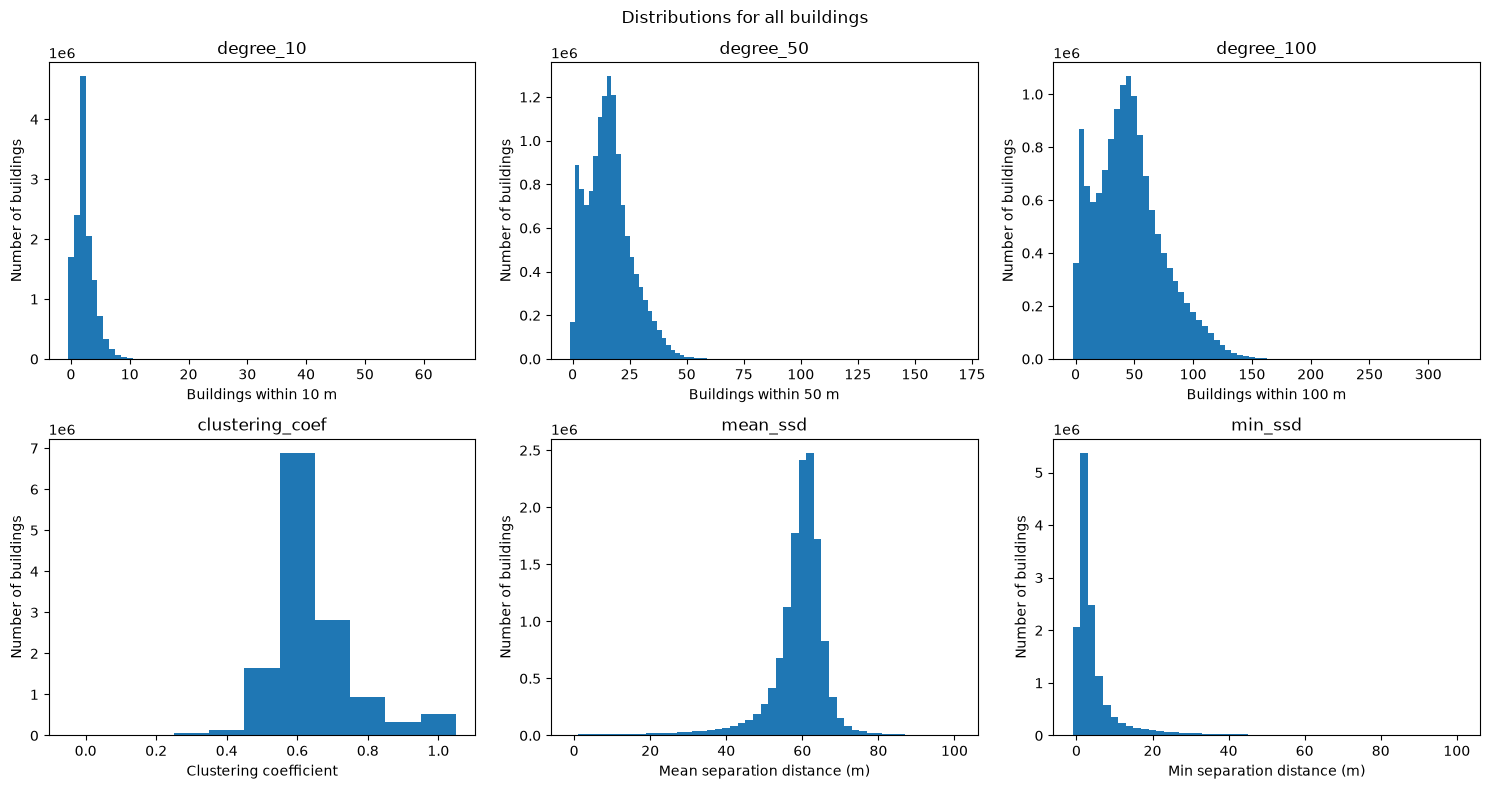

In [2]:
#Read in node data
nodes = gpd.read_parquet("Data/ca_vpdc_nodes.parquet")

#Brief investigation into nodes with no objectid before removing them
no_id = nodes["objectid"].isna()
print(f"{no_id.sum():,} nodes with no objectid. Number of them with a value in each column:")
print(nodes.loc[no_id].notna().sum().to_string())
print(f"Non-empty footprints: {(~nodes.loc[no_id].geometry.is_empty).sum():,}")

# Remove nodes with no objectid. These ~102k rows (0.75%) also have no graph stats (degree,
# clustering coefficient, SSD); they only have a footprint. I am not certain why they are missing, but it is likely they just do not
# have any buildings within 100 m of them to connect. Of the rows with objectid they all have at least 1 building within 100 m.
# These buildings do not need objectid's to connect them to buildings in the edge files because they are not connected to other buildings.

no_id_nodes = nodes.loc[no_id, ["geometry"]].reset_index(drop=True) #Keep them to make sure they are not clustered in a county later
nodes = nodes[~no_id].reset_index(drop=True)

nodes.info()
nodes.head()

nodes["clustering_coef"] = nodes["clustering_coef"].astype(float) #clustering_coef is stored as a decimal type, convert to float

#General summary statistics
overall_summary = summarize_nodes(nodes)

#TODO: Add correlation plots to look for correlations between variables. I am assuming there are some between the degree_* fields at least. 

After removing the rows missing objected values, the only attribute missing data is the clustering_coef. The degree_* attributes are whole numbers, which makes sense because they are counts. The clustering coefficient is between 0 and 1, which a precision of 1 decimal. The mean and min ssd have a lot finer precisions. The degree_* attributions are left-skewed. Clustering_coef, mean_ssd visually somewhat normal. Min_ssd is left-skewed. 

## Differences between ecoregions. Which are the most common types?

15 ecoregions


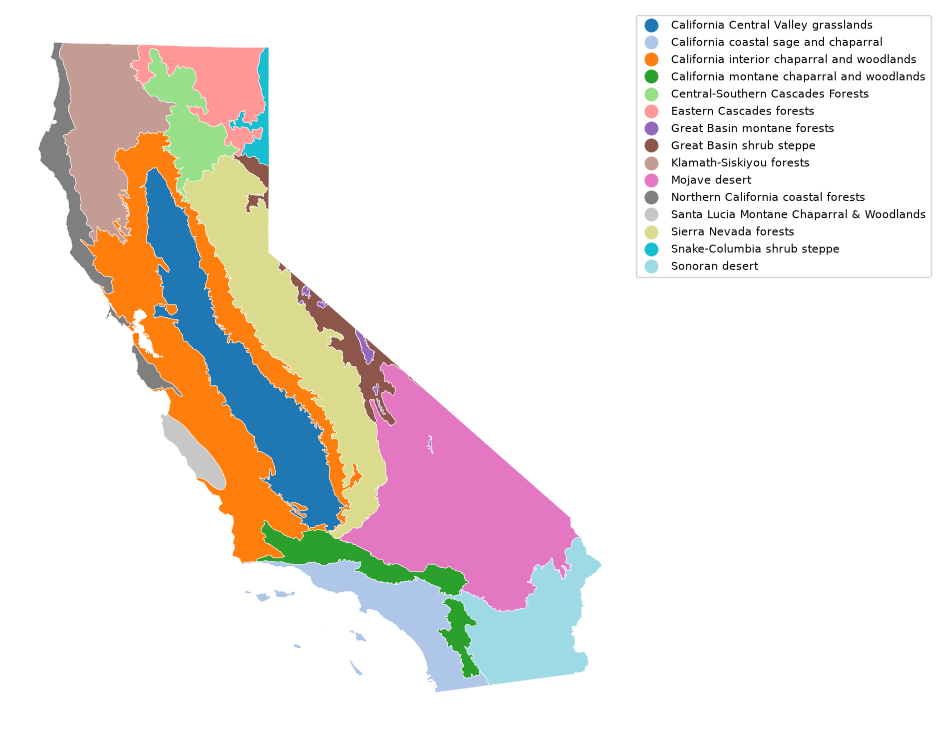

In [3]:
#Read in RESOLVE ecoregions for California

ecoregion_file = Path("Data/ca_ecoregions.gpkg")

if ecoregion_file.exists():
    ecoregions = gpd.read_file(ecoregion_file)
else:
    # RESOLVE Ecoregions 2017 shapefile for the world (~150 MB zip).
    # Downloads once, then saves a California-only copy in Data/ for next time.
    url = "https://storage.googleapis.com/teow2016/Ecoregions2017.zip"
    # bbox (lon/lat) only reads ecoregions near California instead of the whole world
    ecoregions = gpd.read_file(url, bbox=(-124.5, 32.5, -114.0, 42.1))
    ecoregions = ecoregions[["ECO_ID", "ECO_NAME", "BIOME_NAME", "geometry"]]
    # match the nodes' coordinate system (California Albers)
    ecoregions = ecoregions.to_crs(nodes.crs)
    # some polygons in this dataset have invalid geometry, which breaks clipping;
    # "structure" with keep_collapsed=False fixes them and keeps only polygon pieces
    ecoregions["geometry"] = ecoregions.geometry.make_valid(method="structure", keep_collapsed=False)
    # trim to the state outline, dropping any stray line/point slivers the clip creates
    ecoregions = gpd.clip(ecoregions, counties.dissolve(), keep_geom_type=True)
    ecoregions.to_file(ecoregion_file)

print(len(ecoregions), "ecoregions")
ax = ecoregions.plot(column="ECO_NAME", cmap="tab20", legend=True, edgecolor="white", linewidth=0.3, figsize=(8, 10),
                     legend_kwds={"loc": "upper left", "bbox_to_anchor": (1, 1), "fontsize": 8}) #Plot to make sure it looks right
ax.set_axis_off()

1203 nodes not in any ecoregion


### Number of nodes by ecoregion

,n_nodes,percent
ecoregion,,
California coastal sage and chaparral,"6,236,465",46.10
California interior chaparral and woodlands,"3,368,535",24.90
California Central Valley grasslands,"2,432,113",17.98
Mojave desert,"407,244",3.01
Sonoran desert,"313,551",2.32
Sierra Nevada forests,"253,885",1.88
Northern California coastal forests,"186,583",1.38
California montane chaparral and woodlands,"116,795",0.86
Santa Lucia Montane Chaparral & Woodlands,"61,670",0.46


### degree_10 by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,2.720,2.000,1.703,0.000,2.000,4.000,50.000
California interior chaparral and woodlands,"3,368,535",0,2.263,2.000,1.681,0.000,1.000,3.000,65.000
nan,"1,203",0,2.177,2.000,2.192,0.000,1.000,3.000,16.000
Sonoran desert,"313,551",0,2.054,2.000,1.384,0.000,1.000,3.000,32.000
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,2.038,2.000,1.656,0.000,1.000,3.000,15.000
California Central Valley grasslands,"2,432,113",0,1.824,2.000,1.196,0.000,1.000,2.000,38.000
Mojave desert,"407,244",0,1.398,1.000,1.206,0.000,0.000,2.000,26.000
Northern California coastal forests,"186,583",0,1.263,1.000,1.295,0.000,0.000,2.000,22.000
Great Basin shrub steppe,"28,790",0,1.091,1.000,1.163,0.000,0.000,2.000,9.000


...

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,18.150,17.000,9.429,0.000,11.000,24.000,131.000
California interior chaparral and woodlands,"3,368,535",0,15.836,15.000,10.541,0.000,8.000,22.000,149.000
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,13.480,12.000,9.935,0.000,5.000,21.000,69.000
Sonoran desert,"313,551",0,13.309,13.000,8.033,0.000,8.000,17.000,77.000
California Central Valley grasslands,"2,432,113",0,12.797,13.000,7.032,0.000,8.000,17.000,167.000
nan,"1,203",0,10.390,8.000,8.702,0.000,4.000,14.000,40.000
Mojave desert,"407,244",0,9.445,8.000,6.988,0.000,4.000,14.000,66.000
Northern California coastal forests,"186,583",0,8.386,6.000,7.269,0.000,2.000,13.000,79.000
Great Basin shrub steppe,"28,790",0,7.390,5.000,6.626,0.000,2.000,12.000,39.000


### clustering_coef by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
nan,"1,161",42,0.792,0.800,0.144,0.300,0.700,0.900,1.000
Snake-Columbia shrub steppe,"1,768",333,0.788,0.800,0.197,0.300,0.600,1.000,1.000
Klamath-Siskiyou forests,"41,109","9,072",0.772,0.800,0.200,0.200,0.600,1.000,1.000
Eastern Cascades forests,"29,776","4,098",0.750,0.700,0.193,0.100,0.600,1.000,1.000
Great Basin montane forests,167,15,0.746,0.700,0.169,0.300,0.600,0.900,1.000
Great Basin shrub steppe,"26,877","1,913",0.704,0.700,0.173,0.200,0.600,0.800,1.000
Northern California coastal forests,"176,239","10,344",0.698,0.700,0.165,0.200,0.600,0.800,1.000
Sierra Nevada forests,"231,651","22,234",0.688,0.700,0.182,0.100,0.600,0.800,1.000
California montane chaparral and woodlands,"110,669","6,126",0.684,0.600,0.164,0.100,0.600,0.800,1.000


### mean_ssd by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,59.807,60.577,6.002,0.000,57.595,63.056,99.965
California interior chaparral and woodlands,"3,368,535",0,58.529,60.210,9.194,0.000,56.524,62.978,99.988
Mojave desert,"407,244",0,58.003,59.810,11.047,0.000,55.422,63.076,99.981
California Central Valley grasslands,"2,432,113",0,57.719,59.813,9.741,0.000,56.137,62.507,99.981
Sonoran desert,"313,551",0,57.404,58.998,9.118,0.000,54.783,62.111,99.929
California montane chaparral and woodlands,"116,795",0,57.246,59.809,12.988,0.000,53.421,64.019,99.862
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,57.024,59.586,11.634,0.000,54.657,62.855,99.930
Central-Southern Cascades Forests,"34,500",0,56.907,59.126,14.427,0.000,51.681,64.758,99.904
Sierra Nevada forests,"253,885",0,56.293,59.077,15.072,0.000,51.294,64.425,99.967


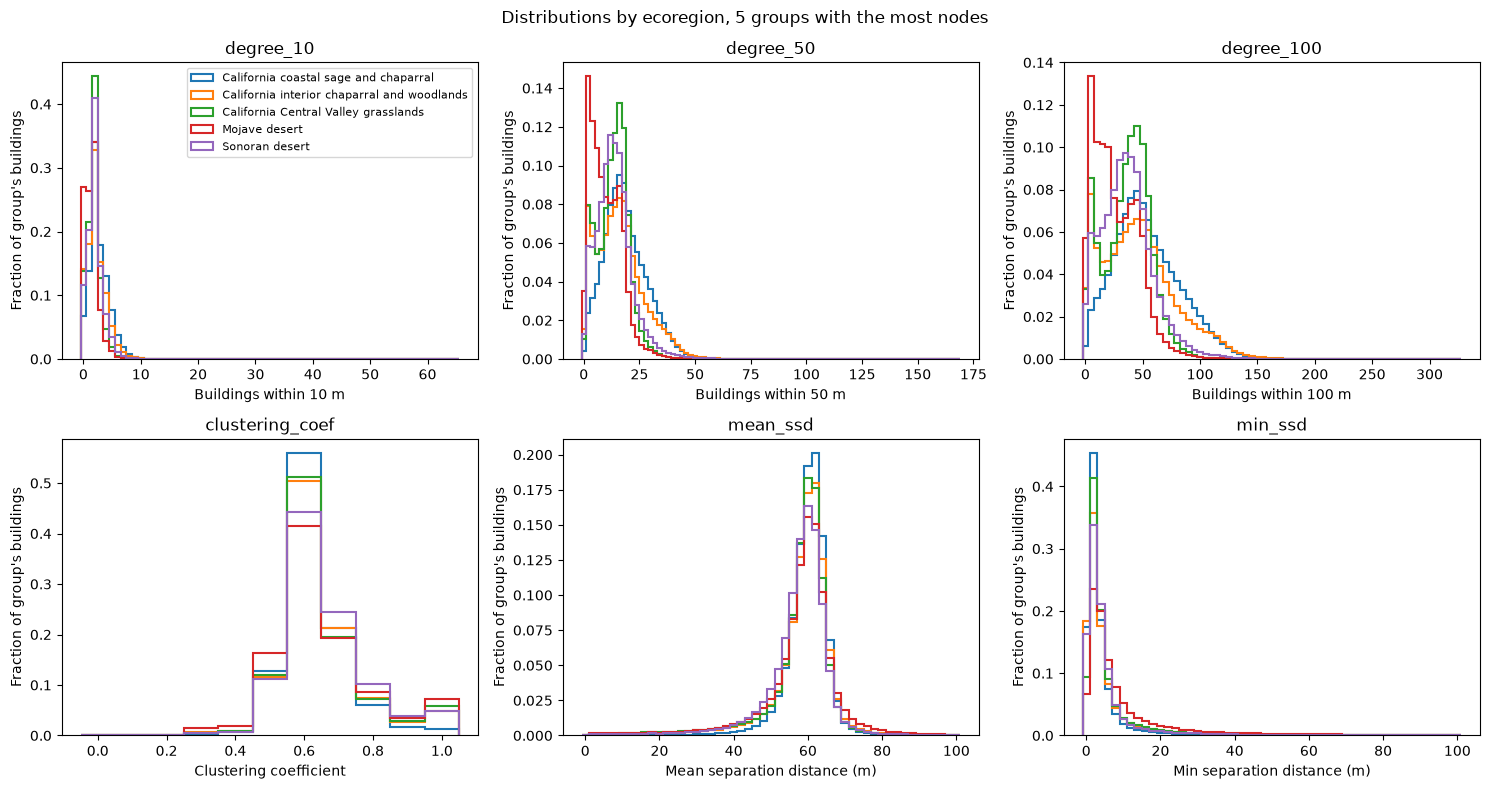

In [4]:
#Assign an ecoregion to each node

#Use one point inside each building footprint so every building gets exactly one ecoregion,
#even if its footprint crosses an ecoregion line
points = gpd.GeoDataFrame(geometry=nodes.geometry.representative_point(), crs=nodes.crs)

# reuses the one-point-per-building layer from the county assignment cell
joined = gpd.sjoin(points, ecoregions, how="left", predicate="within") 

joined = joined[~joined.index.duplicated()] #Guard against a point matching two ecoregions (keeps the first match)

nodes["ecoregion"] = joined["ECO_NAME"]
nodes["biome"] = joined["BIOME_NAME"]

print(nodes["ecoregion"].isna().sum(), "nodes not in any ecoregion")

#Summary stats and histograms by ecoregion
ecoregion_summary = summarize_nodes(nodes, "ecoregion")

Most of the buildings are in the California coastal sage and chaparral and then California interior chaparral and woodlands; California central valley grasslands. The least amount of buildings are in the great basin montane forests. These are not standardized by size of the ecoregions: great basin montane forests appears to be one of the smallest if not the smallest ecoregions in California. The California coastal sage and chaparral and California interior chaparral and woodlands also have the highest degree_10 values, which makes sense. If there are more buildings – likely because it’s a population center – they have more other buildings near it. Differences between county (shown below) are probably more informative groupings than ecoregions in terms of how buildings are structured. 1,203 buildings were not assigned an ecoregion, which I am going to ignore for this basic exploration. In a more detailed exploration or analysis, I would look more into why these were not assigned ecoregions. 

## Explore differences between counties

Which counties are the buildings most connected?

58 counties


<Axes: >

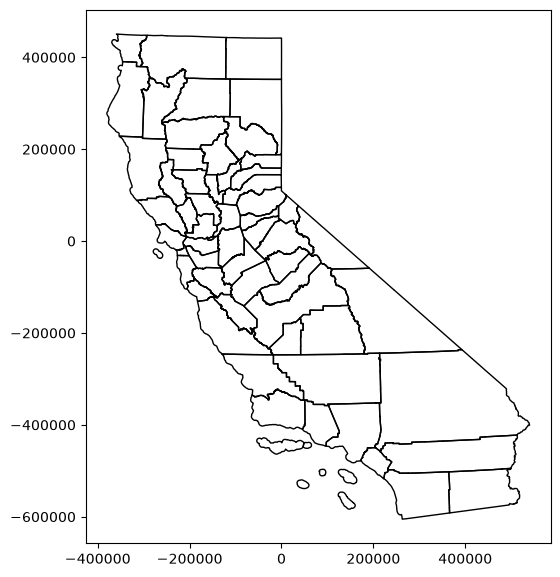

In [5]:
#Read in California county boundaries
if county_file.exists(): #If the county file has already been downloaded read it in, if not download it
    counties = gpd.read_file(county_file)
else:
    #Census TIGER/Line county boundaries for the US, filtered to California (state FIPS 06).
    counties = gpd.read_file(county_url)
    counties = counties[counties["STATEFP"] == "06"][["GEOID", "NAME", "geometry"]]
    counties = counties.rename(columns={"GEOID": "county_fips", "NAME": "county"})
    # match the nodes' coordinate system (California Albers)
    counties = counties.to_crs(nodes.crs)
    counties.to_file(county_file)

print(len(counties), "counties")
counties.plot(edgecolor="black", facecolor="none", figsize=(6, 7)) #Plot to make sure they look right

253 nodes not in any county


### Number of nodes by county

,n_nodes,percent
county,,
Los Angeles,"3,108,193",22.98
San Diego,"1,015,671",7.51
Riverside,"897,321",6.63
Orange,"831,875",6.15
San Bernardino,"754,085",5.57
Santa Clara,"601,878",4.45
Sacramento,"522,166",3.86
Alameda,"511,905",3.78
Contra Costa,"387,840",2.87


### degree_10 by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,3.808,4.000,1.471,0.000,3.000,4.000,39.000
Los Angeles,"3,108,193",0,3.272,3.000,1.795,0.000,2.000,4.000,50.000
nan,253,0,3.020,2.000,3.604,0.000,1.000,4.000,16.000
Alameda,"511,905",0,2.951,3.000,1.788,0.000,2.000,4.000,30.000
Santa Clara,"601,878",0,2.776,2.000,1.688,0.000,2.000,4.000,51.000
Orange,"831,875",0,2.516,2.000,1.441,0.000,2.000,3.000,43.000
San Mateo,"235,239",0,2.440,2.000,1.502,0.000,2.000,3.000,22.000
Monterey,"160,342",0,2.185,2.000,1.659,0.000,1.000,3.000,23.000
Imperial,"82,069",0,2.146,2.000,1.611,0.000,1.000,3.000,20.000


...

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,31.828,33.000,9.580,0.000,27.000,38.000,87.000
Los Angeles,"3,108,193",0,21.574,21.000,9.669,0.000,15.000,28.000,100.000
Alameda,"511,905",0,21.292,20.000,10.537,0.000,14.000,28.000,88.000
San Mateo,"235,239",0,18.368,18.000,9.292,0.000,12.000,24.000,80.000
Santa Clara,"601,878",0,18.125,18.000,9.189,0.000,12.000,23.000,107.000
Orange,"831,875",0,16.678,16.000,7.637,0.000,12.000,20.000,131.000
Contra Costa,"387,840",0,14.989,14.000,8.819,0.000,9.000,19.000,119.000
Sacramento,"522,166",0,14.384,15.000,6.445,0.000,10.000,18.000,63.000
San Diego,"1,015,671",0,14.350,13.000,8.933,0.000,8.000,19.000,93.000


### clustering_coef by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
nan,234,19,0.849,0.900,0.146,0.300,0.800,1.000,1.000
Mariposa,"15,860","3,069",0.787,0.800,0.210,0.200,0.600,1.000,1.000
Modoc,"8,260","1,520",0.777,0.800,0.194,0.200,0.600,1.000,1.000
Trinity,"9,844","2,094",0.751,0.700,0.204,0.200,0.600,1.000,1.000
Tehama,"36,993","4,110",0.736,0.700,0.191,0.200,0.600,0.900,1.000
Glenn,"16,716","1,328",0.733,0.700,0.185,0.100,0.600,0.900,1.000
Siskiyou,"33,668","4,337",0.733,0.700,0.189,0.100,0.600,0.900,1.000
Alpine,"1,421",215,0.727,0.700,0.195,0.300,0.600,0.900,1.000
Sierra,"2,743",353,0.726,0.700,0.179,0.200,0.600,0.900,1.000


### mean_ssd by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,60.429,61.132,4.244,0.000,58.813,62.862,99.652
Los Angeles,"3,108,193",0,60.311,61.000,5.406,0.000,58.234,63.324,99.965
Alameda,"511,905",0,60.127,60.853,5.599,0.000,58.084,63.190,99.964
Santa Clara,"601,878",0,59.945,60.812,6.277,0.000,57.867,63.278,99.663
San Mateo,"235,239",0,59.591,60.484,6.393,0.000,57.629,62.849,99.909
Orange,"831,875",0,59.392,60.015,5.169,0.000,57.105,62.413,99.948
San Bernardino,"754,085",0,59.382,60.446,8.291,0.000,56.987,63.283,99.981
Sacramento,"522,166",0,59.378,60.236,6.327,0.000,57.479,62.524,99.941
Contra Costa,"387,840",0,59.287,60.117,6.314,0.000,56.992,62.695,99.929


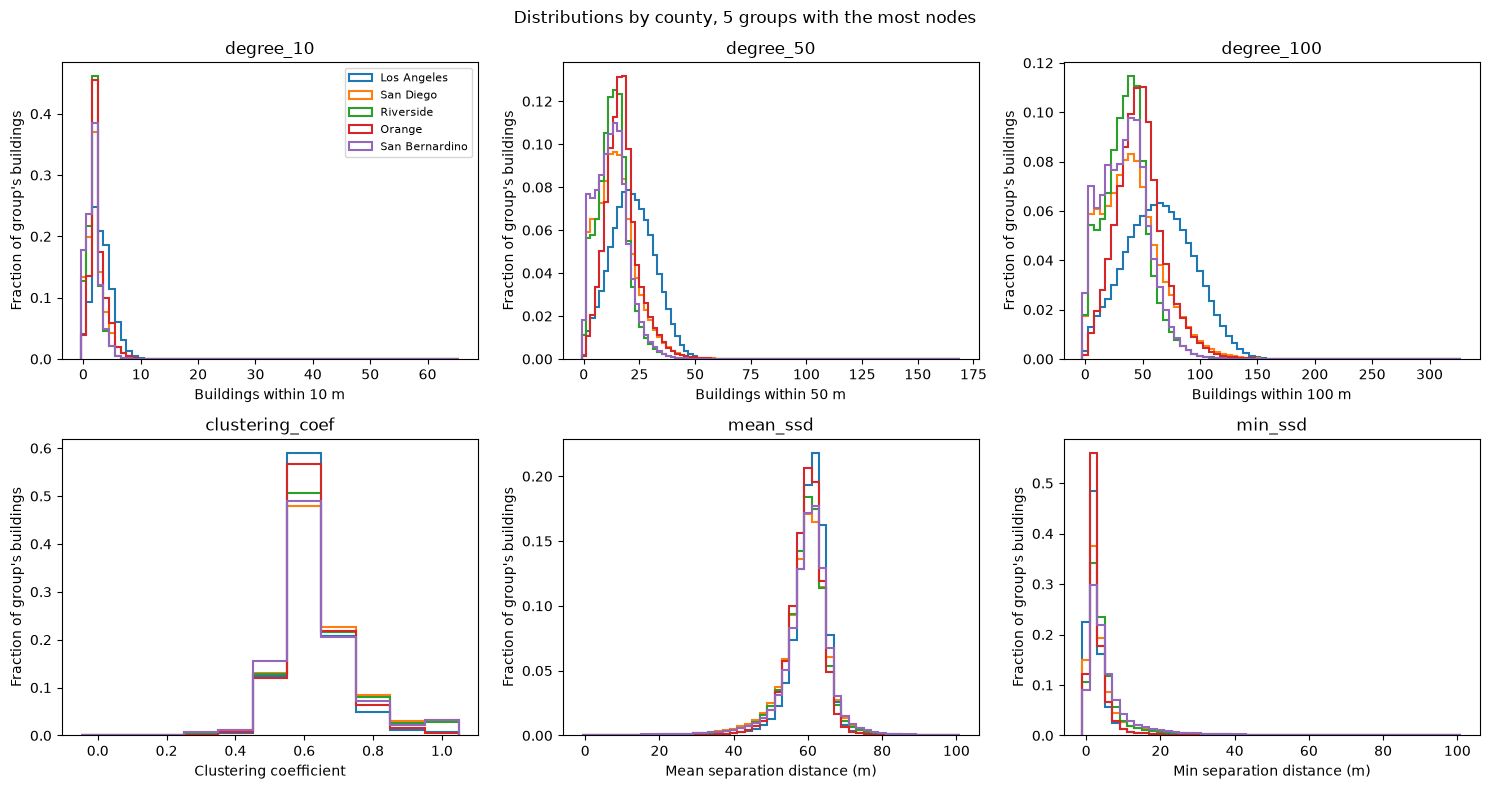

In [6]:
#Assign a county to each node
joined = gpd.sjoin(points, counties, how="left", predicate="within") #Reuses points from ecoregion assignment

joined = joined[~joined.index.duplicated()] #Guard against a point matching two counties (keeps the first match)

nodes["county"] = joined["county"]
nodes["county_fips"] = joined["county_fips"]

print(nodes["county"].isna().sum(), "nodes not in any county")

#Summary stats and histograms by county
county_summary = summarize_nodes(nodes, "county")

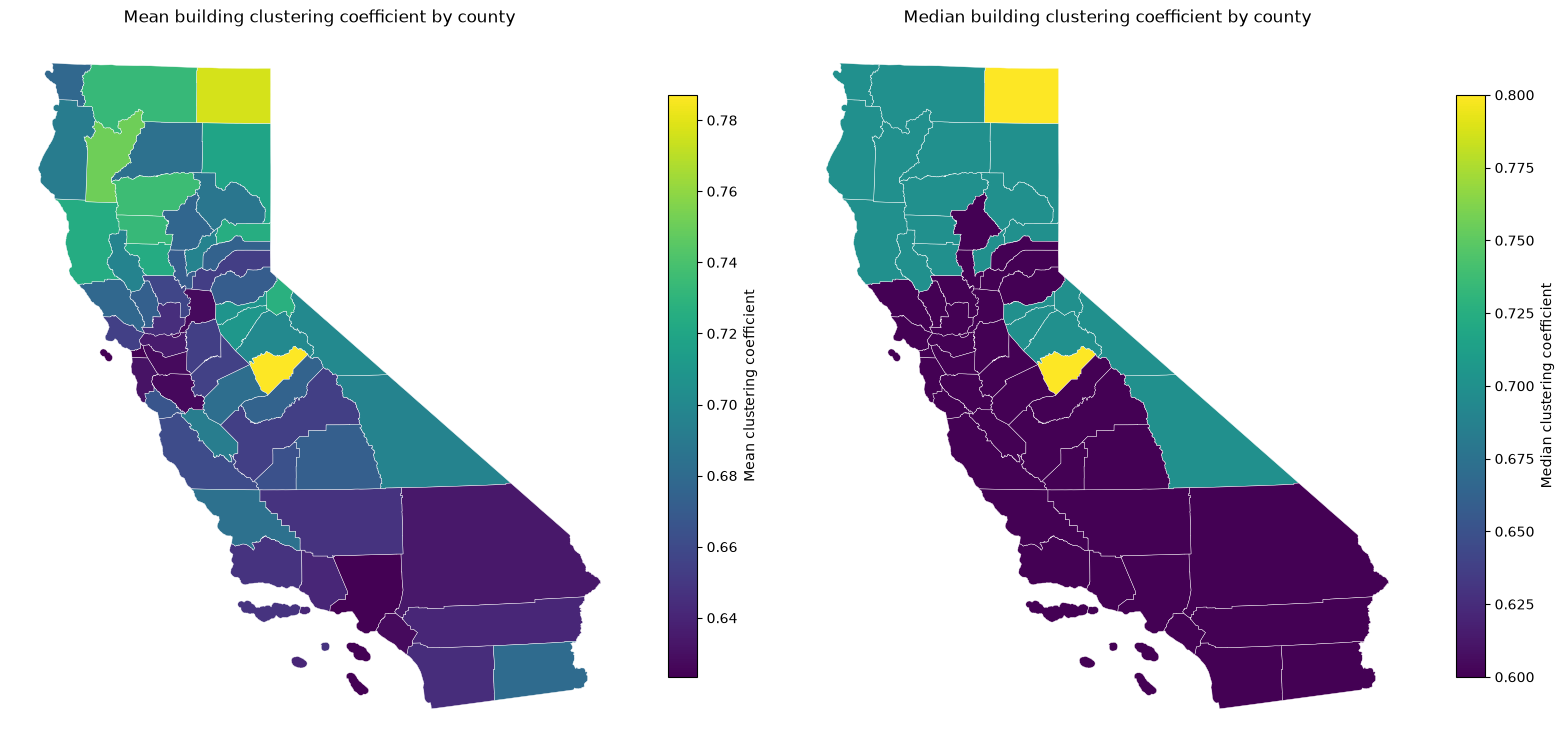

In [7]:
#Choropleth maps of mean and median clustering coefficient per county

#Mean and median skip buildings with no clustering_coef; n_with_coef is how many went into each
county_clustering = (
    nodes.groupby("county_fips")["clustering_coef"]
    .agg(mean_clustering="mean", median_clustering="median", n_with_coef="count")
    .reset_index()
)

counties_clustering = counties.merge(county_clustering, on="county_fips", how="left")


fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, stat in zip(axes, ["mean_clustering", "median_clustering"], ["Mean", "Median"]):
    counties_clustering.plot(
        column=col,
        cmap="viridis",
        legend=True,
        legend_kwds={"label": f"{stat} clustering coefficient", "shrink": 0.6},
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
    )
    ax.set_title(f"{stat} building clustering coefficient by county")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

#TODO: label highest 2 and lowest 2
#TODO: investigate how strong correlations between county average attributes are

Los Angeles as expected has the most buildings. 253 buildings were not assigned a county: I am going to ignore those here as it is a basic exploration, but would further investigate those in a more detailed exploration. San Francisco, however, has the highest building average for the number of other buildings within 10 m of it, followed by Los Angeles. Same for degree_50. The buildings not assigned a county have the highest average clustering_coef. They are probably within a cluster themselves. The county with the highest average clustering_coef is Mariposa, which is a little surprising to me. But it is next to Yosemite so there are probably either stricter zoning laws or just less roads so buildings have to be next to each other. Los Angeles and San Franscisco have the two lowest average clustering_coef values. San Francisco and Los Angeles have the highest mean mean_ssd and Mariposa is third lowest (Modoc second lowest and missing county lowest). Los Angeles has a relatively normal distribution of degree_50 and degree_100, but most (of the other counties with high numbers of buildings) are more left-skewed. There is a lot more uniform variation in the map of mean county clustering_coef than median county clustering_coef. This makes sense because the median are actual values and they have precisions of 1 decimal place so they can only be 0.6, 0.7, and 0.8 here, whereas the mean can reflect more of the distribution of values within the county. 

In [8]:
#Counties of the nodes removed for having no objectid (check to make sure they are not concentrated)

#Same approach as the county assignment above: one point inside each footprint
no_id_points = gpd.GeoDataFrame(geometry=no_id_nodes.geometry.representative_point(), crs=no_id_nodes.crs)
no_id_joined = gpd.sjoin(no_id_points, counties, how="left", predicate="within")
no_id_joined = no_id_joined[~no_id_joined.index.duplicated()]

no_id_by_county = no_id_joined["county"].value_counts(dropna=False).rename("n_removed").to_frame()
no_id_by_county["percent_of_removed"] = 100 * no_id_by_county["n_removed"] / len(no_id_joined)
no_id_by_county.style.format({"n_removed": "{:,}", "percent_of_removed": "{:.1f}"})

#They are pretty spread out so it does not seem like they are just a spot that vibrant planet had not gotten to calculating values for yet. 

,n_removed,percent_of_removed
county,,
San Bernardino,"6,334",6.2
Kern,"5,480",5.3
San Diego,"4,959",4.8
Mendocino,"4,491",4.4
Fresno,"4,254",4.2
Riverside,"4,113",4.0
Tulare,"3,692",3.6
Humboldt,"3,197",3.1
San Luis Obispo,"3,186",3.1


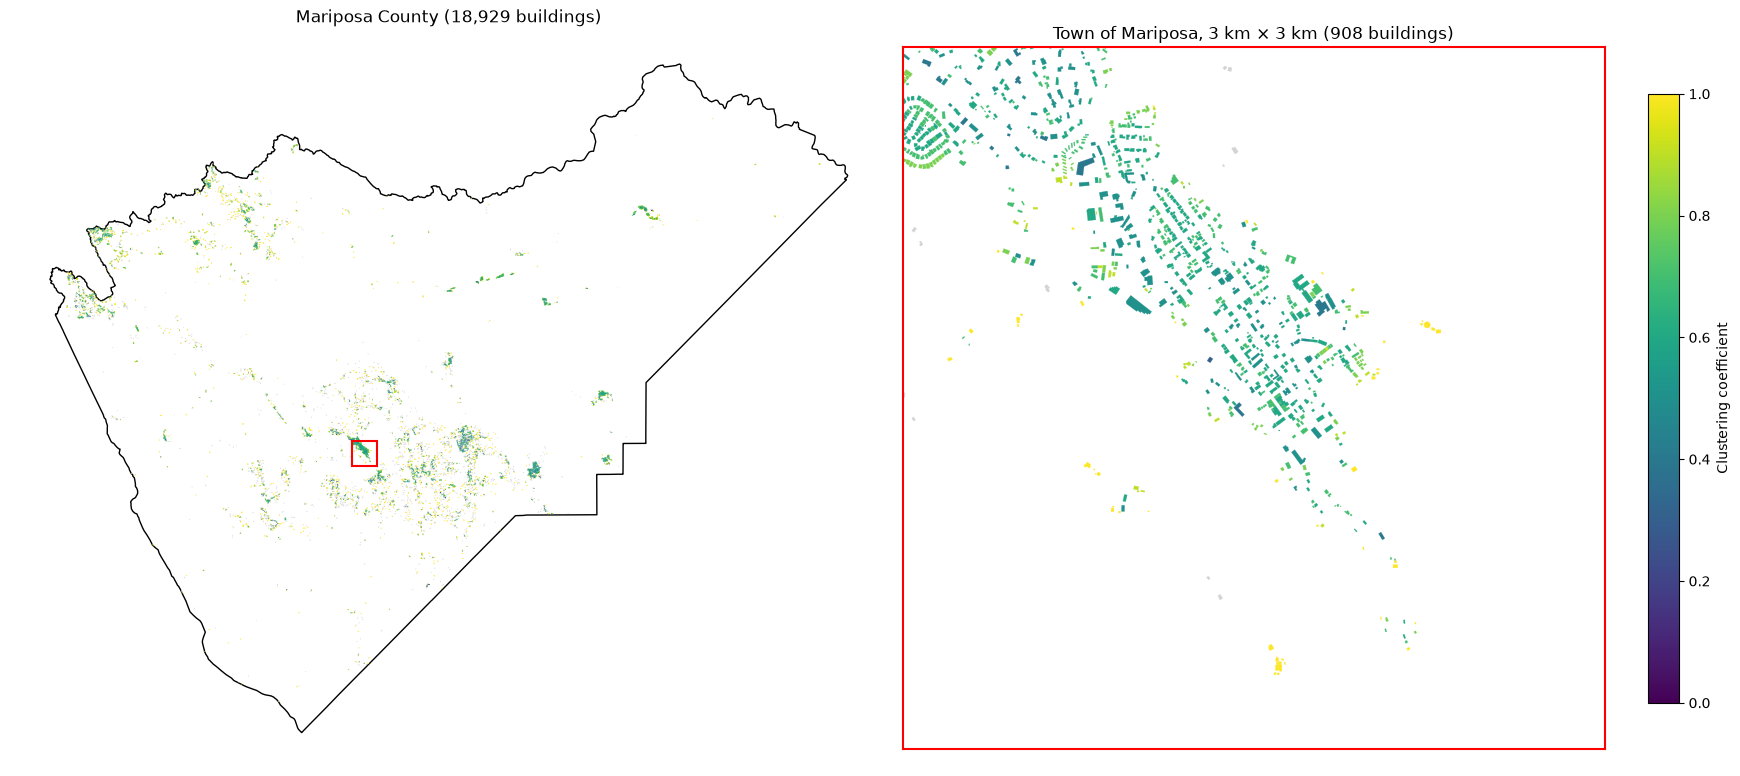

In [9]:
#Map of buildings in Mariposa County colored by clustering coefficient

mariposa_buildings = nodes[nodes["county"] == "Mariposa"]
mariposa_outline = counties[counties["county"] == "Mariposa"]

#Zoom window: a 3 km square centered on the town of Mariposa
town_center = gpd.GeoSeries([Point(-119.9663, 37.4849)], crs="EPSG:4326").to_crs(nodes.crs).iloc[0]
half_width = 1500  # meters
xmin, xmax = town_center.x - half_width, town_center.x + half_width
ymin, ymax = town_center.y - half_width, town_center.y + half_width
town_buildings = mariposa_buildings.cx[xmin:xmax, ymin:ymax]

fig, (ax_county, ax_town) = plt.subplots(1, 2, figsize=(18, 9))

#Same color scale on both panels so colors match between them
plot_kwds = dict(
    column="clustering_coef",
    cmap="viridis",
    vmin=0,
    vmax=1,
    edgecolor="face",
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

#County panel: at this scale most buildings are smaller than a pixel, so outline
#Each one in its fill color to keep it visible
mariposa_outline.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax_county)
mariposa_buildings.plot(linewidth=0.5, ax=ax_county, **plot_kwds)
ax_county.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, edgecolor="red", linewidth=1.5))
ax_county.set_title(f"Mariposa County ({len(mariposa_buildings):,} buildings)")
ax_county.set_axis_off()

#Town panel: building footprints are big enough to see their shapes
town_buildings.plot(
    linewidth=0.2,
    legend=True,
    legend_kwds={"label": "Clustering coefficient", "shrink": 0.7},
    ax=ax_town,
    **plot_kwds,
)
ax_town.set_xlim(xmin, xmax)
ax_town.set_ylim(ymin, ymax)
ax_town.set_title(f"Town of Mariposa, 3 km × 3 km ({len(town_buildings):,} buildings)")
#Hide the ticks but keep a red frame to match the box on the county panel
ax_town.set_xticks([])
ax_town.set_yticks([])
for spine in ax_town.spines.values():
    spine.set_edgecolor("red")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

## Differences between land use land cover types

Structure should have more of an impact in more vegetation-sparse environments. In environments with lots of trees it should not matter as much how connected the buildings are.

Steps:
Read in LULC dataset
Assign LULC
Look at differences between land cover types
How does filtering LULC affect which counties have the most connectivity? 

## Proximity to the Riley et al. (2025) dataset

If Open Climate Risk has focused on spread from wildlands to urban areas, how much of these building data are close to the wildlands? 

Find dataset and see how easy it is to download to decide if you want to include

## How to connectivities compare to the current estimated risk in Open Climate Risk?

Need to figure out what counties to focus on


## Social justice. How do structural characteristics compare to places predominately non-white, average income, etc. 

## Some interesting places to make maps of connections between buildings 